In [6]:
import urllib
import pandas as pd
from sqlalchemy import create_engine

# Define and format the connection string parameters for SQL Server
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=RestaurantAnalytics;"
    "Trusted_Connection=yes;"
)

# Create the SQLAlchemy engine to establish a robust connection
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Define the SQL query to retrieve monthly performance data from the view
query = "SELECT * FROM vw_MonthlyRestaurantPerformance"
# Execute the query and load the results directly into a Pandas DataFrame
df = pd.read_sql(query, engine)

# Display the first 5 rows of the DataFrame to verify the data
print(df.head())

   RestaurantID           Name  PerformanceYear  PerformanceMonth  \
0             4          Anteb             2025                 6   
1             3         Tavern             2026                 1   
2             5       Tumanyan             2024                11   
3             5       Tumanyan             2025                 4   
4             9  Cherkezi Dzor             2025                10   

   TotalTransactions  TotalRevenue  AverageOrderValue  
0                 37      606800.0       16400.000000  
1                 47      688700.0       14653.191489  
2                 37      578500.0       15635.135135  
3                 31      487200.0       15716.129032  
4                 25      429700.0       17188.000000  


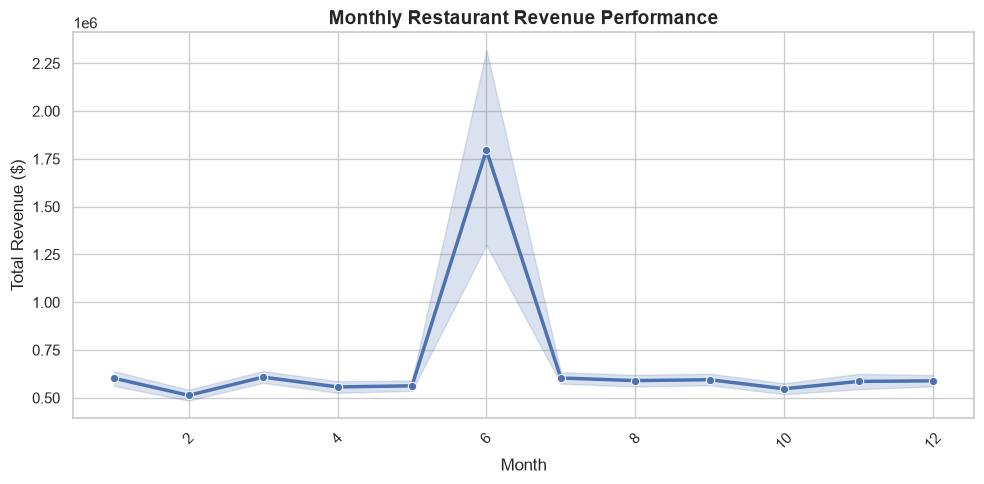

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a figure for Monthly Revenue Trend
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="PerformanceMonth",
    y="TotalRevenue",
    marker="o",
    color="b",
    linewidth=2.5,
)

# Add titles and labels with professional English
plt.title(
    "Monthly Restaurant Revenue Performance", fontsize=14, fontweight="bold"
)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)

# Rotate x-axis labels if needed for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

   RestaurantName  PerformanceMonth  TotalTransactions  TotalRevenue
0       Semoi Mot                 1                 52      832700.0
1      Craftsmens                 1                 48      827400.0
2   Cherkezi Dzor                 1                 45      716100.0
3  Pandok Yerevan                 1                 47      708900.0
4          Lavash                 1                 44      706800.0


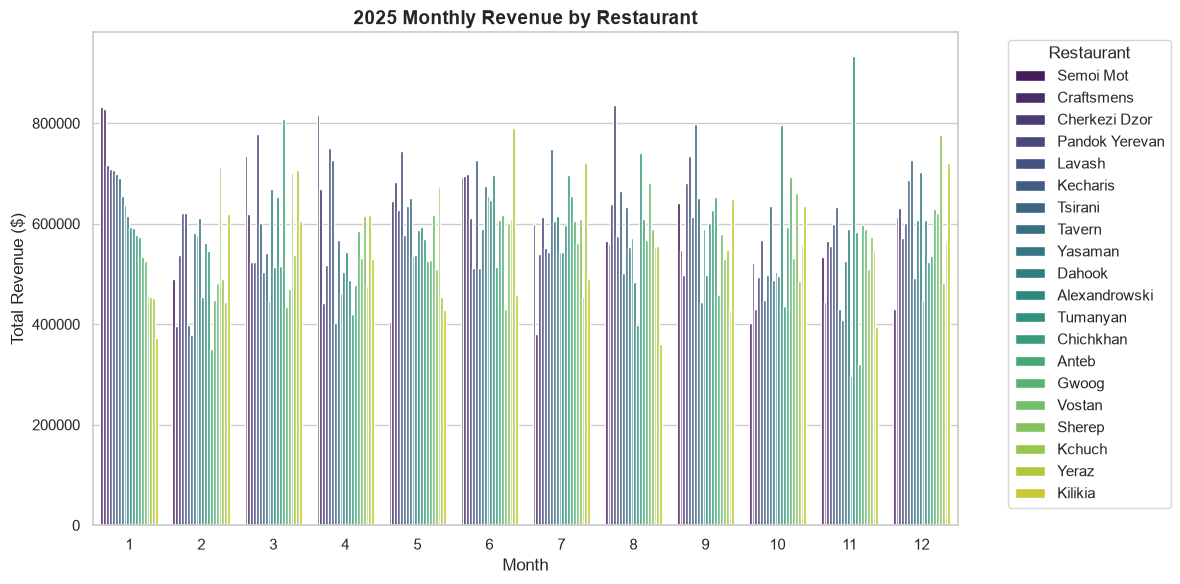

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Write the custom SQL query directly joining the base tables for the year 2025
query_2025 = """
SELECT
    r.Name AS RestaurantName,
    MONTH(t.TransactionDate) AS PerformanceMonth,
    COUNT(t.TransactionID) AS TotalTransactions,
    SUM(t.TotalAmount) AS TotalRevenue
FROM Restaurants r
JOIN Transactions t
    ON r.RestaurantID = t.RestaurantID
WHERE YEAR(t.TransactionDate) = 2025
GROUP BY r.Name, MONTH(t.TransactionDate)
ORDER BY PerformanceMonth, TotalRevenue DESC
"""

# 2. Load the data directly into a Pandas DataFrame
df_2025 = pd.read_sql(query_2025, engine)

# 3. Display the first few rows to verify the fetched data
print(df_2025.head())

# 4. Create a professional visualization using Seaborn
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Barplot to show total revenue by restaurant across months in 2025
sns.barplot(
    data=df_2025,
    x="PerformanceMonth",
    y="TotalRevenue",
    hue="RestaurantName",
    palette="viridis",
)

# 5. Add titles, labels, and formatting
plt.title(
    "2025 Monthly Revenue by Restaurant", fontsize=14, fontweight="bold"
)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.legend(title="Restaurant", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()